# Gaussian Difference 파라미터 탐색

한 장씩 Gaussian blur/threshold 파라미터를 조절해 원본, 차이맵, 이진 마스크, 채워진 마스크를 비교합니다. 마지막 저장 셀을 실행한 경우에만 해당 이미지의 mask와 YOLO segmentation label을 저장합니다.

In [ ]:
from pathlib import Path
import cv2
import matplotlib.pyplot as plt
import numpy as np
from pseudo_labeller import GaussianDifferenceConfig
from pseudo_labeller.image_io import ImageRepository
from pseudo_labeller.processing import GaussianDifferenceMaskMaker, YoloSegmentationExporter

[556/1110] F:\0918_data\0918_data_raw\case07\02\000\13000us\mono_20260917_224125_076455.png


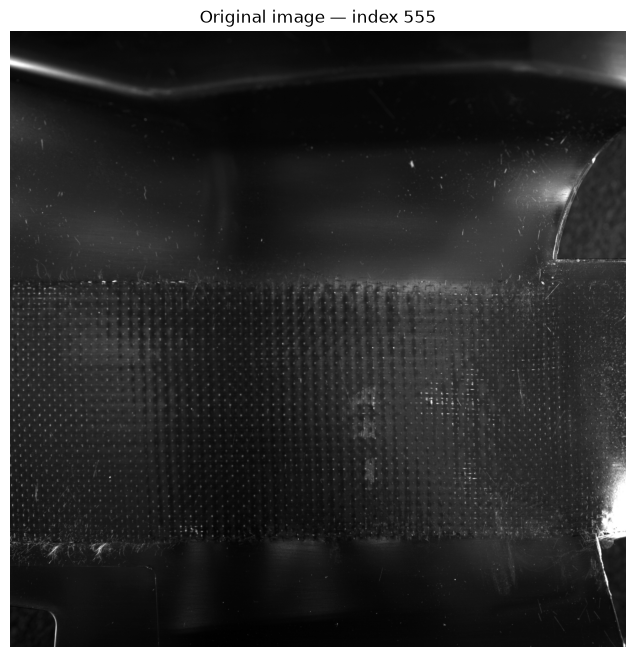

In [2]:
# 경로 및 검토할 이미지 선택
INPUT_ROOT = Path(r"F:\0918_data")
MASK_OUTPUT_ROOT = Path(r'F:\__pseudo_labeller\02_pseudo_labeller\processed\0918_pseudo_masks')
LABEL_OUTPUT_ROOT = Path(r'F:\__pseudo_labeller\02_pseudo_labeller\processed\0918_pseudo_yolo_labels')
IMAGE_EXTENSIONS = {'.bmp', '.jpeg', '.jpg', '.png', '.tif', '.tiff'}

image_paths = sorted(
    path for path in INPUT_ROOT.rglob('*')
    if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
)
if not image_paths:
    raise FileNotFoundError(f'지원되는 이미지가 없습니다: {INPUT_ROOT}')

IMAGE_INDEX = int(input(f'확인할 이미지 인덱스를 입력하세요 (0 ~ {len(image_paths) - 1}): '))
if not 0 <= IMAGE_INDEX < len(image_paths):
    raise IndexError(f'IMAGE_INDEX는 0 ~ {len(image_paths) - 1} 범위여야 합니다.')

input_path = image_paths[IMAGE_INDEX]
image = ImageRepository.read(input_path)
if image is None:
    raise OSError(f'이미지를 읽을 수 없습니다: {input_path}')

print(f'[{IMAGE_INDEX + 1}/{len(image_paths)}] {input_path}')
plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB) if image.ndim == 3 else image, cmap=None if image.ndim == 3 else 'gray')
plt.title(f'Original image — index {IMAGE_INDEX}')
plt.axis('off')
plt.show()

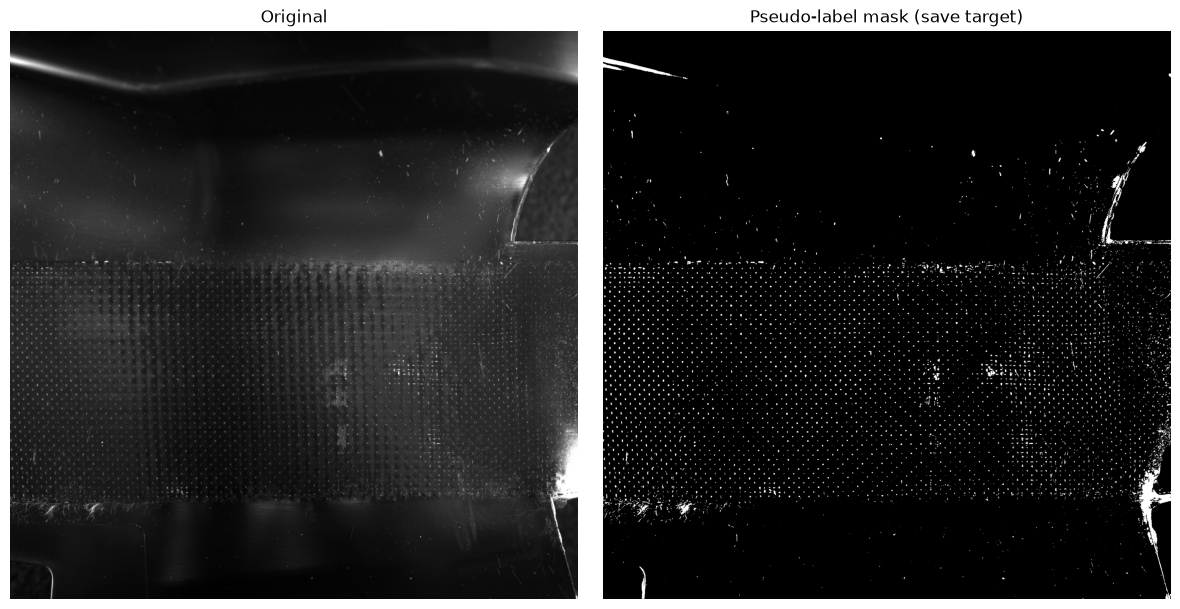

kernel=101, sigma=10.0, threshold=None, min_area=0.0


In [3]:
# 이 셀의 값만 바꾼 뒤, 아래 미리보기 셀을 다시 실행하세요.
GAUSSIAN_KERNEL_SIZE = 101  # 양의 홀수. 클수록 더 강하게 블러 처리
GAUSSIAN_SIGMA = 10.0      # 0이면 OpenCV가 kernel size로부터 계산
MASK_THRESHOLD = None     # None: Otsu 자동 임계값, 0~255: 고정 임계값
MIN_CONTOUR_AREA = 0.0
CONTOUR_APPROXIMATION_RATIO = 0.00
POST_MASK_GAUSSIAN_KERNEL_SIZE = 5  # selected_mask 후처리용 양의 홀수
POST_MASK_GAUSSIAN_SIGMA = 0.0
CLASS_ID = 0
CLASS_NAME = 'Exposure'

if GAUSSIAN_KERNEL_SIZE <= 0 or GAUSSIAN_KERNEL_SIZE % 2 == 0:
    raise ValueError('GAUSSIAN_KERNEL_SIZE는 양의 홀수여야 합니다.')
if MASK_THRESHOLD is not None and not 0 <= MASK_THRESHOLD <= 255:
    raise ValueError('MASK_THRESHOLD는 None 또는 0~255 정수여야 합니다.')
if POST_MASK_GAUSSIAN_KERNEL_SIZE <= 0 or POST_MASK_GAUSSIAN_KERNEL_SIZE % 2 == 0:
    raise ValueError('POST_MASK_GAUSSIAN_KERNEL_SIZE는 양의 홀수여야 합니다.')

# 현재 파라미터로 실제 저장될 수도 라벨링 마스크를 즉시 미리보기합니다.
config = GaussianDifferenceConfig(
    input_root=INPUT_ROOT,
    mask_output_root=MASK_OUTPUT_ROOT,
    label_output_root=LABEL_OUTPUT_ROOT,
    class_id=CLASS_ID,
    class_name=CLASS_NAME,
    min_contour_area=MIN_CONTOUR_AREA,
    contour_approximation_ratio=CONTOUR_APPROXIMATION_RATIO,
    gaussian_kernel_size=GAUSSIAN_KERNEL_SIZE,
    gaussian_sigma=GAUSSIAN_SIGMA,
    mask_threshold=MASK_THRESHOLD,
)
filled_mask = GaussianDifferenceMaskMaker(config).create(image)
smoothed_mask = cv2.GaussianBlur(
    filled_mask,
    (POST_MASK_GAUSSIAN_KERNEL_SIZE, POST_MASK_GAUSSIAN_KERNEL_SIZE),
    POST_MASK_GAUSSIAN_SIGMA,
)
_, selected_mask = cv2.threshold(smoothed_mask, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB) if image.ndim == 3 else image, cmap=None if image.ndim == 3 else 'gray')
axes[0].set_title('Original')
axes[1].imshow(selected_mask, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('Pseudo-label mask (save target)')
for axis in axes:
    axis.axis('off')
plt.tight_layout()
plt.show()
print(f'kernel={GAUSSIAN_KERNEL_SIZE}, sigma={GAUSSIAN_SIGMA}, threshold={MASK_THRESHOLD}, min_area={MIN_CONTOUR_AREA}')

In [4]:
# 원본 코드와 동일한 Gaussian difference 중간 결과를 포함한 미리보기 함수
def create_preview(image: np.ndarray, config: GaussianDifferenceConfig):
    blurred = cv2.GaussianBlur(
        image, (config.gaussian_kernel_size, config.gaussian_kernel_size), config.gaussian_sigma
    )
    difference = image.astype(np.int16) - blurred.astype(np.int16)
    scalar_difference = difference.mean(axis=2) if difference.ndim == 3 else difference
    difference_map = np.abs(scalar_difference).clip(0, 255).astype(np.uint8)
    threshold_type = cv2.THRESH_BINARY if config.mask_threshold is not None else cv2.THRESH_BINARY + cv2.THRESH_OTSU
    _, raw_mask = cv2.threshold(difference_map, config.mask_threshold or 0, 255, threshold_type)
    filled_mask = GaussianDifferenceMaskMaker(config).fill_regions(raw_mask)
    return blurred, difference_map, raw_mask, filled_mask

def show_image(axis, image, title: str):
    if image.ndim == 3:
        axis.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    else:
        axis.imshow(image, cmap='gray', vmin=0, vmax=255)
    axis.set_title(title)
    axis.axis('off')

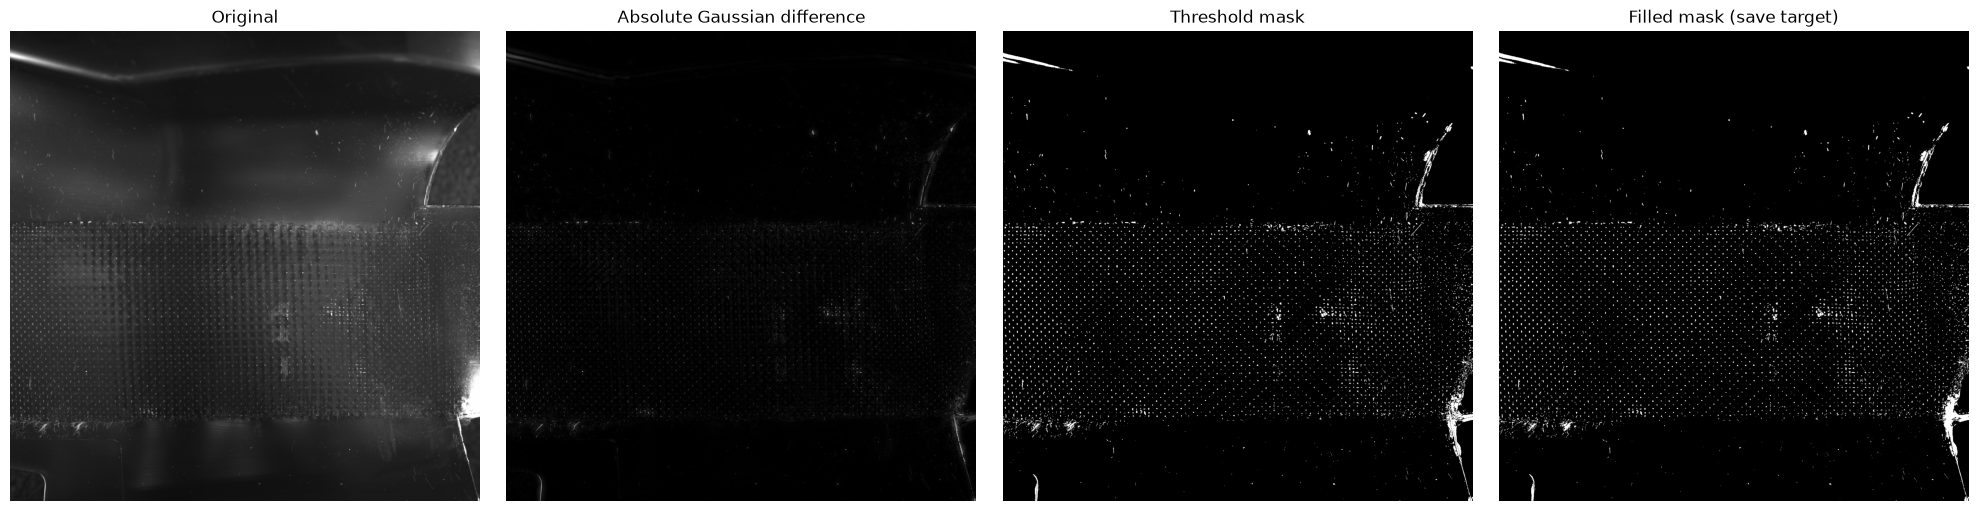

kernel=101, sigma=10.0, threshold=None, min_area=0.0


In [5]:
# 미리보기: 파라미터를 바꾼 뒤 이 셀만 반복 실행
config = GaussianDifferenceConfig(
    input_root=INPUT_ROOT,
    mask_output_root=MASK_OUTPUT_ROOT,
    label_output_root=LABEL_OUTPUT_ROOT,
    class_id=CLASS_ID,
    class_name=CLASS_NAME,
    min_contour_area=MIN_CONTOUR_AREA,
    contour_approximation_ratio=CONTOUR_APPROXIMATION_RATIO,
    gaussian_kernel_size=GAUSSIAN_KERNEL_SIZE,
    gaussian_sigma=GAUSSIAN_SIGMA,
    mask_threshold=MASK_THRESHOLD,
)
image = ImageRepository.read(input_path)
if image is None:
    raise OSError(f'이미지를 읽을 수 없습니다: {input_path}')

blurred, difference_map, raw_mask, filled_mask = create_preview(image, config)
smoothed_mask = cv2.GaussianBlur(
    filled_mask,
    (POST_MASK_GAUSSIAN_KERNEL_SIZE, POST_MASK_GAUSSIAN_KERNEL_SIZE),
    POST_MASK_GAUSSIAN_SIGMA,
)
_, selected_mask = cv2.threshold(smoothed_mask, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
fig, axes = plt.subplots(1, 5, figsize=(25, 5))
show_image(axes[0], image, 'Original')
show_image(axes[1], difference_map, 'Absolute Gaussian difference')
show_image(axes[2], raw_mask, 'Threshold mask')
show_image(axes[3], filled_mask, 'Filled mask (before post-Gaussian)')
show_image(axes[4], selected_mask, 'Post-Gaussian binary mask (save target)')
plt.tight_layout()
plt.show()
print(f'kernel={GAUSSIAN_KERNEL_SIZE}, sigma={GAUSSIAN_SIGMA}, threshold={MASK_THRESHOLD}, min_area={MIN_CONTOUR_AREA}')
print(f'post-mask kernel={POST_MASK_GAUSSIAN_KERNEL_SIZE}, sigma={POST_MASK_GAUSSIAN_SIGMA}')

## 선택 결과 저장

미리보기가 만족스러울 때만 다음 셀을 실행하세요. `selected_mask`와 현재 파라미터를 사용하여 같은 상대 경로에 PNG/TIFF 등의 mask와 `.txt` YOLO label을 저장합니다.

In [6]:
"""# 저장 셀 — 의도적으로 이 셀을 실행할 때만 파일이 생성됩니다.
# 예: INPUT_ROOT/a01/000/image.png -> processed/.../a01/000/image.png
relative_path = input_path.relative_to(INPUT_ROOT)  # 입력 루트 아래의 트리를 그대로 사용
mask_path = MASK_OUTPUT_ROOT / relative_path
label_path = (LABEL_OUTPUT_ROOT / relative_path).with_suffix('.txt')
print(f'Input relative path: {relative_path}')
print(f'Mask output path:   {mask_path}')
print(f'Label output path:  {label_path}')

mask_path.parent.mkdir(parents=True, exist_ok=True)
if not ImageRepository.write(mask_path, selected_mask):
    raise OSError(f'mask를 저장할 수 없습니다: {mask_path}')

labels = YoloSegmentationExporter(config).create_labels(selected_mask)
label_path.parent.mkdir(parents=True, exist_ok=True)
label_path.write_text('\n'.join(labels) + ('\n' if labels else ''), encoding='utf-8')
for filename in ('labelmap.txt', 'classes.txt'):
    (LABEL_OUTPUT_ROOT / filename).write_text(CLASS_NAME.strip() + '\n', encoding='utf-8')

print(f'Saved mask: {mask_path}')
print(f'Saved label ({len(labels)} region(s)): {label_path}')"""

"# 저장 셀 — 의도적으로 이 셀을 실행할 때만 파일이 생성됩니다.\n# 예: INPUT_ROOT/a01/000/image.png -> processed/.../a01/000/image.png\nrelative_path = input_path.relative_to(INPUT_ROOT)  # 입력 루트 아래의 트리를 그대로 사용\nmask_path = MASK_OUTPUT_ROOT / relative_path\nlabel_path = (LABEL_OUTPUT_ROOT / relative_path).with_suffix('.txt')\nprint(f'Input relative path: {relative_path}')\nprint(f'Mask output path:   {mask_path}')\nprint(f'Label output path:  {label_path}')\n\nmask_path.parent.mkdir(parents=True, exist_ok=True)\nif not ImageRepository.write(mask_path, selected_mask):\n    raise OSError(f'mask를 저장할 수 없습니다: {mask_path}')\n\nlabels = YoloSegmentationExporter(config).create_labels(selected_mask)\nlabel_path.parent.mkdir(parents=True, exist_ok=True)\nlabel_path.write_text('\n'.join(labels) + ('\n' if labels else ''), encoding='utf-8')\nfor filename in ('labelmap.txt', 'classes.txt'):\n    (LABEL_OUTPUT_ROOT / filename).write_text(CLASS_NAME.strip() + '\n', encoding='utf-8')\n\nprint(f'Saved mask: {mask_path}')\nprin